In [30]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)


In [31]:
# Laden der Daten
df = pd.read_csv('../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv')
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('time')
df = df.resample('d').sum()
y = df['estermannufer']
y = y.values.reshape(-1, 1)
df.head()

,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer
time,,,,,,,,,
2016-01-16,256,50,2212,173,333,249,210,271,361
2016-01-17,164,59,1533,230,358,316,220,339,358
2016-01-18,559,145,5055,442,1633,783,566,792,1387
2016-01-19,581,151,6233,483,1658,770,586,743,1279
2016-01-20,513,141,5167,425,1543,668,505,612,1199


In [32]:
# Daten skallieren
scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(y)
y = scaler.transform(y)

In [33]:
# Input generieren
n_lookback = 365*4  # Länge des Inputs für die Vorhersage
n_forecast = 365 # Länge der Vorhersage

X = []
Y = []

for i in range(n_lookback, len(y) - n_forecast + 1):
    X.append(y[i - n_lookback: i])
    Y.append(y[i: i + n_forecast])

X = np.array(X)
Y = np.array(Y)

In [34]:
# Das Model trainieren
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(n_lookback, 1)))
model.add(LSTM(units=50))
model.add(Dense(n_forecast))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='estermannufer.keras', monitor='val_loss', save_best_only=True)
ester = model.fit(X, Y, batch_size=32, epochs=100, shuffle=True, validation_split = 0.1, callbacks=[early, check], verbose=1)

Epoch 1/100


/home/leonidas/Uni/Semester_5_24_25/Datenanalyse/Projekt/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 342ms/step - loss: 0.0458 - mae: 0.1655 - val_loss: 0.0214 - val_mae: 0.1232
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step - loss: 0.0212 - mae: 0.1177 - val_loss: 0.0200 - val_mae: 0.1183
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step - loss: 0.0206 - mae: 0.1161 - val_loss: 0.0202 - val_mae: 0.1201
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 348ms/step - loss: 0.0202 - mae: 0.1154 - val_loss: 0.0202 - val_mae: 0.1203
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 355ms/step - loss: 0.0201 - mae: 0.1151 - val_loss: 0.0197 - val_mae: 0.1193
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step - loss: 0.0202 - mae: 0.1143 - val_loss: 0.0190 - val_mae: 0.1152
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step - loss: 0.0191 - mae: 0.1095 - val_loss: 0.0194 - val_mae: 0.1159
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - loss: 0.0186 - mae: 0.1071 - val_loss: 0.0194 - val_mae: 0.1156
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 352ms/ste

In [35]:
# Vorhersage
X_ = y[- n_lookback:]
X_ = X_.reshape(1, n_lookback, 1)

Y_ = model.predict(X_).reshape(-1, 1)
Y_ = scaler.inverse_transform(Y_)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


In [36]:
# Ergebnisse organisieren
df_past = df[['estermannufer']].reset_index()
df_past['time'] = pd.to_datetime(df_past['time'])
df_past['Forecast'] = np.nan
df_past['Forecast'].iloc[-1] = df_past['estermannufer'].iloc[-1]
df_past

/tmp/ipykernel_14797/57600970.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_past['Forecast'].iloc[-1] = df_past['estermannufer'].iloc[-1]
/tmp/ipykernel_14797/57600970.py:5: SettingWithCopyWarning: 
A value is trying to be set on a 

,time,estermannufer,Forecast
0,2016-01-16,50,NaN
1,2016-01-17,59,NaN
2,2016-01-18,145,NaN
3,2016-01-19,151,NaN
4,2016-01-20,141,NaN
...,...,...,...
2902,2023-12-27,0,NaN
2903,2023-12-28,0,NaN
2904,2023-12-29,3,NaN
2905,2023-12-30,96,NaN


In [37]:
df_future = pd.DataFrame(columns=['time', 'estermannufer', 'Forecast'])
df_future['time'] = pd.date_range(start=df_past['time'].iloc[-1] + pd.Timedelta(hours=1), periods=n_forecast)
df_future['Forecast'] = Y_.flatten()
df_future['estermannufer'] = np.nan
df_future

,time,estermannufer,Forecast
0,2023-12-31 01:00:00,NaN,408.548706
1,2024-01-01 01:00:00,NaN,393.051117
2,2024-01-02 01:00:00,NaN,404.473480
3,2024-01-03 01:00:00,NaN,429.280884
4,2024-01-04 01:00:00,NaN,407.859863
...,...,...,...
360,2024-12-25 01:00:00,NaN,323.445892
361,2024-12-26 01:00:00,NaN,273.154816
362,2024-12-27 01:00:00,NaN,347.209961
363,2024-12-28 01:00:00,NaN,283.480774


In [38]:
results = pd.concat([df_past, df_future])
results = results.set_index('time')
results.head()

,estermannufer,Forecast
time,,
2016-01-16,50.0,NaN
2016-01-17,59.0,NaN
2016-01-18,145.0,NaN
2016-01-19,151.0,NaN
2016-01-20,141.0,NaN


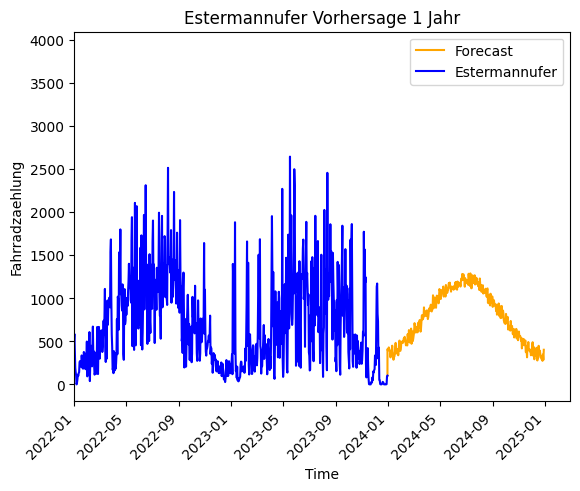

In [44]:
# Ergebnisse plotten
plt.plot(results['Forecast'], color = 'orange', label = 'Forecast')
plt.plot(results['estermannufer'], color = 'blue', label = 'Estermannufer')
plt.title('Estermannufer Vorhersage 1 Jahr')
plt.xlabel('Time')
plt.ylabel('Fahrradzaehlung')
plt.legend()
start_date = datetime(2022, 1, 1)
end_date = datetime(2025, 3, 1)
plt.xlim(start_date, end_date)
#plt.ylim(0,1300)
plt.xticks(rotation=45, ha='right')
plt.show()

Text(0, 0.5, 'loss')

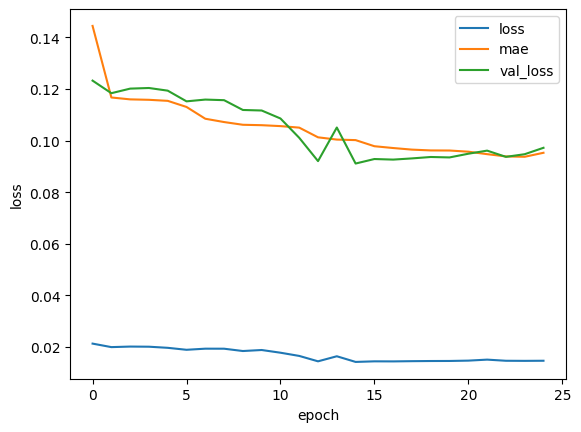

In [40]:
plt.plot(ester.history['val_loss'])
plt.plot(ester.history['mae'])
plt.plot(ester.history['val_mae'])
plt.legend(['loss', 'mae', 'val_loss', 'val_mae'])
plt.xlabel('epoch')
plt.ylabel('loss')

In [41]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1460, 50)       │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 365)            │        18,615 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,647 (576.75 KB)

 Trainable params: 49,215 (192.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,432 (384.50 KB)